Nascite e tasso di fecondità in Italia

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
df=pd.read_csv('C:/Users/Margherita/Downloads/Nati per età madre e totale nati.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Area             76 non-null     object
 1   Anno             76 non-null     int64 
 2   Nati             76 non-null     int64 
 3   Meno di 15 anni  76 non-null     int64 
 4   15-19            76 non-null     int64 
 5   20-24            76 non-null     int64 
 6   25-29            76 non-null     int64 
 7   30-34            76 non-null     int64 
 8   35-39            76 non-null     int64 
 9   40-44            76 non-null     int64 
 10  45-49            76 non-null     int64 
 11  50 anni e più    76 non-null     int64 
dtypes: int64(11), object(1)
memory usage: 7.3+ KB


In [25]:
# Seleziona colonne e righe
df_nati=df.iloc[3:, [1, 2]].reset_index(drop=True)
df_nati.head()

,Anno,Nati
0,1952,844447
1,1953,839478
2,1954,870689
3,1955,869333
4,1956,873608


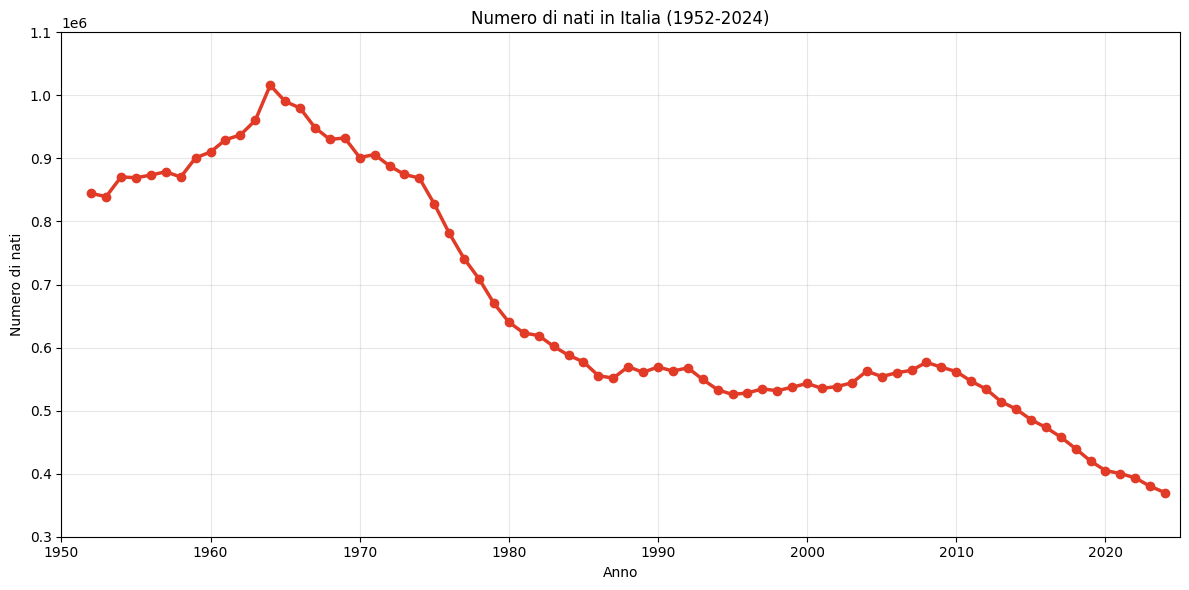

In [26]:
#Grafico
plt.figure(figsize=(12, 6))
plt.plot(df_nati['Anno'], df_nati['Nati'],
         marker='o', linewidth=2.5, color='#E13B27')
plt.title('Numero di nati in Italia (1952-2024)')
plt.xlabel('Anno')
plt.xlim(left=1950, right=2025)
plt.ylabel('Numero di nati')
plt.ylim(bottom=300000, top=1100000)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('andamento_nascite.png', dpi=300)
plt.show()

In [27]:
df_fecondità=pd.read_excel('C:/Users/Margherita/Downloads/Tassi di fecondità totale per ripartizione geografica - Anni 1952-2024.xlsx')
df_fecondità.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Anni        73 non-null     int64  
 1   Nord-ovest  73 non-null     float64
 2   Nord-est    73 non-null     float64
 3   Centro      73 non-null     float64
 4   Sud         73 non-null     float64
 5   Isole       73 non-null     float64
 6   Italia      73 non-null     float64
dtypes: float64(6), int64(1)
memory usage: 4.1 KB


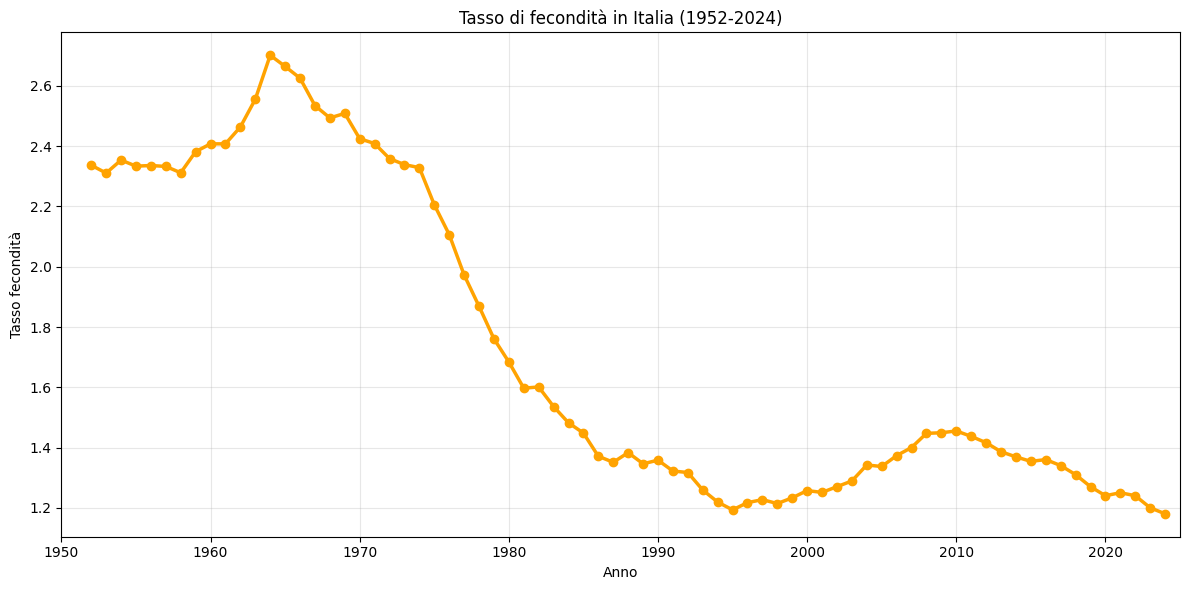

In [28]:
plt.figure(figsize=(12, 6))
plt.plot(df_fecondità['Anni'], df_fecondità['Italia'],
         marker='o', linewidth=2.5, color='#FFA301')
plt.title('Tasso di fecondità in Italia (1952-2024)')
plt.xlabel('Anno')
plt.xlim(left=1950, right=2025)
plt.ylabel("Tasso fecondità")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tasso_fecondità.png', dpi=300)
plt.show()

Previsioni


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

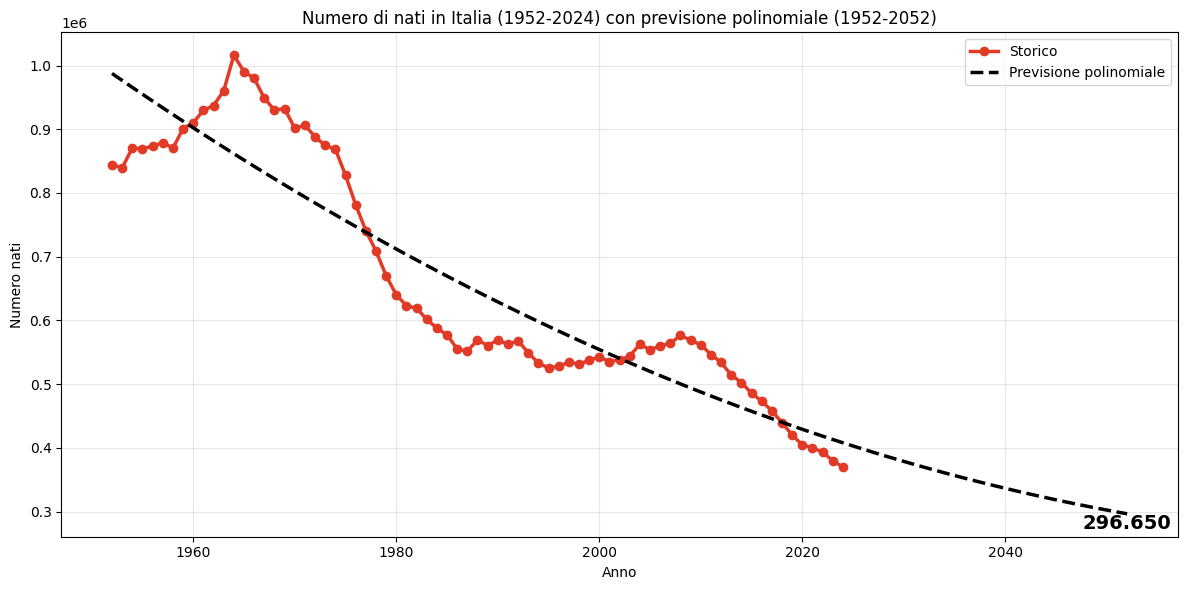

In [33]:
#Nati in Italia con previsione con curva polimiale
X=df_nati['Anno'].values.reshape(-1,1)
y=df_nati['Nati'].values
poly=PolynomialFeatures(degree=2)
X_poly=poly.fit_transform(X)

model=LinearRegression()
model.fit(X_poly, y)

#Previsione fino al 2052
anni_futuri=np.arange(df_nati['Anno'].max()+1, 2053)
anni_tot=np.concatenate([df_nati['Anno'], anni_futuri])
anni_tot_poly=poly.transform(anni_tot.reshape(-1,1))
y_pred=model.predict(anni_tot_poly)

#Grafico
plt.figure(figsize=(12,6))
plt.plot(df_nati['Anno'], df_nati['Nati'],
         marker='o', linewidth=2.5, color='#E13B27', 
         label='Storico')
plt.plot(anni_tot, y_pred,
         linestyle='dashed', linewidth=2.5, color='black', 
         label='Previsione polinomiale')

#Nati nel 2052
anno_2052=np.array([[2052]])
valore_2052 = model.predict(poly.transform(anno_2052))[0]

plt.text(2052, valore_2052,
         f'{int(valore_2052):,}'.replace(',', '.'),
         fontsize=14, fontweight='bold',
         ha='center', va='top')

plt.title('Numero di nati in Italia (1952-2024) con previsione polinomiale (1952-2052)')
plt.xlabel('Anno')
plt.ylabel('Numero nati')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('andamento_nascite_previsione_polinomiale.png', dpi=300)
plt.show()

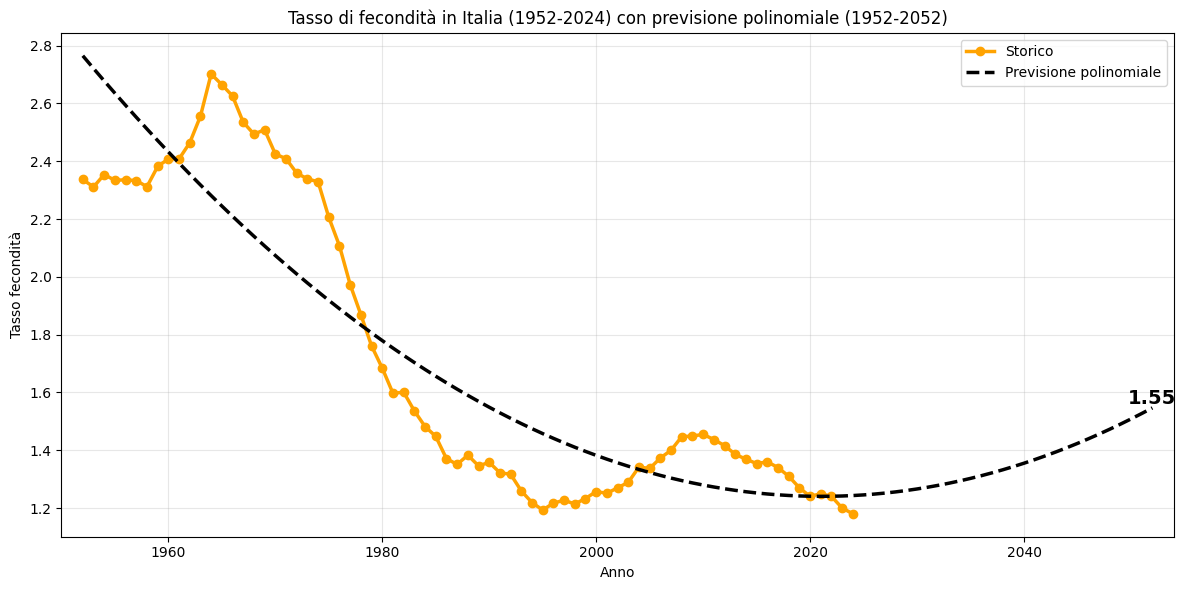

In [34]:
#Tasso fecondità con previsione con curva polinomiale
X=df_fecondità['Anni'].values.reshape(-1, 1)
y=df_fecondità['Italia'].values
poly=PolynomialFeatures(degree=2)
X_poly=poly.fit_transform(X)

model=LinearRegression()
model.fit(X_poly, y)

#Previsione fino al 2052
TF_futuro=np.arange(df_fecondità['Anni'].max()+1, 2053)
TF_tot=np.concatenate([df_fecondità['Anni'], TF_futuro])
TF_tot_poly=poly.transform(TF_tot.reshape(-1, 1))
y_pred=model.predict(TF_tot_poly)

#Grafico
plt.figure(figsize=(12, 6))
plt.plot(df_fecondità['Anni'], df_fecondità['Italia'],
         marker='o', linewidth=2.5, color='#FFA301', 
         label='Storico')
plt.plot(anni_tot, y_pred,
         linestyle='dashed', linewidth=2.5, color='black',
         label='Previsione polinomiale')
plt.title('Tasso di fecondità in Italia (1952-2024) con previsione polinomiale (1952-2052)')
plt.xlabel('Anno')
plt.xlim(left=1950, right=2054)
plt.ylabel("Tasso fecondità")
plt.grid(True, alpha=0.3)
plt.legend()

#Valore 2052
anno_2052 = np.array([[2052]])
valore_2052 = model.predict(poly.transform(anno_2052))[0]

plt.text(2052, valore_2052,
         f'{valore_2052:.2f}',
         fontsize=14, fontweight='bold',
         ha='center', va='bottom')

plt.tight_layout()
plt.savefig('tasso_fecondità_previsione_polinomiale.png', dpi=300)
plt.show()


Età della popolazione 1952-2024 e previsione polinomiale

In [50]:
df1=pd.read_csv('C:/Users/Margherita/Downloads/Progetto finale/1952-1971 Ricostruzione intercensuaria della popolazione residente.csv')
df2=pd.read_csv('C:/Users/Margherita/Downloads/Progetto finale/1972-1981 Ricostruzione intercensuaria della popolazione residente.csv')
df3=pd.read_csv('C:/Users/Margherita/Downloads/Progetto finale/1982-1991 Italia, regioni, province.csv')

dfa=pd.concat([df1, df2, df3])
dfa.head()


,FREQ,Frequenza,REF_AREA,Territorio,DATA_TYPE,Indicatore,AGE,Età,SEX,Sesso,TIME_PERIOD,Osservazione,OBS_STATUS,"'Stato dell""'osservazione'"
0,A,Annuale,IT,Italia,JAN,Popolazione al 1º gennaio,Y0,0 anni,9,Totale,1952,817477,NaN,NaN
1,A,Annuale,IT,Italia,JAN,Popolazione al 1º gennaio,Y0,0 anni,9,Totale,1953,818381,NaN,NaN
2,A,Annuale,IT,Italia,JAN,Popolazione al 1º gennaio,Y0,0 anni,9,Totale,1954,819104,NaN,NaN
3,A,Annuale,IT,Italia,JAN,Popolazione al 1º gennaio,Y0,0 anni,9,Totale,1955,842382,NaN,NaN
4,A,Annuale,IT,Italia,JAN,Popolazione al 1º gennaio,Y0,0 anni,9,Totale,1956,842375,NaN,NaN


In [51]:
dfa=dfa[['AGE', 'TIME_PERIOD', 'Osservazione']]
dfa.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4080 entries, 0 to 1019
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   AGE           4080 non-null   object
 1   TIME_PERIOD   4080 non-null   int64 
 2   Osservazione  4080 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 127.5+ KB


In [52]:
dfa['Età_n']=dfa['AGE'].str.extract(r'(\d+)').astype(float)
dfa=dfa.dropna(subset=['Età_n'])
dfa['Età_n']=dfa['Età_n'].astype(int)
dfa=dfa[['Età_n', 'TIME_PERIOD', 'Osservazione']]
dfa.columns=['Età', 'Anno', 'Tot Popolazione']
dfa.head()

,Età,Anno,Tot Popolazione
0,0,1952,817477
1,0,1953,818381
2,0,1954,819104
3,0,1955,842382
4,0,1956,842375


In [53]:
df4=pd.read_csv('C:/Users/Margherita/Downloads/Progetto finale/1992-2001 Italia, regioni, province.csv')
df5=pd.read_csv('C:/Users/Margherita/Downloads/Progetto finale/2002-2019 Italia, regioni, province.csv')

dfb=pd.concat([df4, df5])
dfb.head()

,FREQ,Frequenza,REF_AREA,Territorio,DATA_TYPE,Indicatore,AGE,Età,SEX,Sesso,...,BASE_PER,Anno base,UNIT_MEAS,Unità di misura,UNIT_MULT,Unità di moltiplicazione,CITIZENSHIP,Cittadinanza,NOTE_CITIZENSHIP,Cittadinanza (NOTE_CITIZENSHIP)
0,A,Annuale,IT,Italia,JAN,Popolazione al 1º gennaio,Y0,0 anni,9,Totale,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A,Annuale,IT,Italia,JAN,Popolazione al 1º gennaio,Y0,0 anni,9,Totale,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A,Annuale,IT,Italia,JAN,Popolazione al 1º gennaio,Y0,0 anni,9,Totale,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A,Annuale,IT,Italia,JAN,Popolazione al 1º gennaio,Y0,0 anni,9,Totale,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A,Annuale,IT,Italia,JAN,Popolazione al 1º gennaio,Y0,0 anni,9,Totale,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
dfb=dfb[['AGE', 'TIME_PERIOD', 'Osservazione']]
dfb.head()

,AGE,TIME_PERIOD,Osservazione
0,Y0,1992,510808
1,Y0,1993,570454
2,Y0,1994,548535
3,Y0,1995,532848
4,Y0,1996,522979


In [55]:
dfb['Età_n']=dfb['AGE'].str.extract(r'(\d+)').astype(float)
dfb=dfb.dropna(subset=['Età_n'])
dfb['Età_n']=dfb['Età_n'].astype(int)
dfb=dfb[['Età_n', 'TIME_PERIOD', 'Osservazione']]
dfb.columns=['Età', 'Anno', 'Tot Popolazione']
dfb.head()

,Età,Anno,Tot Popolazione
0,0,1992,510808
1,0,1993,570454
2,0,1994,548535
3,0,1995,532848
4,0,1996,522979


In [59]:
df6=pd.read_csv('C:/Users/Margherita/Downloads/Progetto finale/2020 Italia, regioni, province.csv')
df7=pd.read_csv('C:/Users/Margherita/Downloads/Progetto finale/2021 Italia, regioni, province.csv')
df8=pd.read_csv('C:/Users/Margherita/Downloads/Progetto finale/2022 Italia, regioni, province.csv')
df9=pd.read_csv('C:/Users/Margherita/Downloads/Progetto finale/2023 Italia, regioni, province.csv')
df10=pd.read_csv('C:/Users/Margherita/Downloads/Progetto finale/2024 Italia, regioni, province.csv')

dfc=pd.concat([df6, df7, df8, df9, df10])
dfc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 505 entries, 0 to 100
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   FREQ                        505 non-null    object 
 1   Frequenza                   505 non-null    object 
 2   REF_AREA                    505 non-null    object 
 3   Territorio                  505 non-null    object 
 4   DATA_TYPE                   505 non-null    object 
 5   Indicatore                  505 non-null    object 
 6   SEX                         505 non-null    int64  
 7   Sesso                       505 non-null    object 
 8   AGE                         505 non-null    object 
 9   Età                         505 non-null    object 
 10  MARITAL_STATUS              505 non-null    int64  
 11  Stato civile                505 non-null    object 
 12  TIME_PERIOD                 505 non-null    int64  
 13  Osservazione                505 non-null

In [60]:
dfc=dfc[['AGE', 'TIME_PERIOD', 'Osservazione']]

dfc['Età_n']=dfc['AGE'].str.extract(r'(\d+)').astype(float)
dfc['Età_n']=dfc['Età_n'].astype(int)
dfc=dfc[['Età_n', 'TIME_PERIOD', 'Osservazione']]
dfc.columns=['Età', 'Anno', 'Tot Popolazione']
dfc.head()

,Età,Anno,Tot Popolazione
0,0,2021,404956
1,1,2021,423269
2,2,2021,443571
3,3,2021,464239
4,4,2021,480475


In [67]:
df_età=pd.concat([dfa, dfb, dfc], ignore_index=True)
df_età.head(105)

,Età,Anno,Tot Popolazione
0,0,1952,817477
1,0,1953,818381
2,0,1954,819104
3,0,1955,842382
4,0,1956,842375
...,...,...,...
100,5,1952,903140
101,5,1953,897573
102,5,1954,902530
103,5,1955,843247


In [68]:
#Calcolo media ponderata dell'età della popolazione raggruppata in anni
df_etàmedia=df_età.groupby('Anno').apply(
    lambda x: (x['Età'] * x['Tot Popolazione']).sum() / x['Tot Popolazione'].sum(), include_groups=False
).round(1).reset_index(name='Età_media')

df_etàmedia.tail(72)

,Anno,Età_media
1,1953,31.7
2,1954,31.9
3,1955,32.1
4,1956,32.3
5,1957,32.4
...,...,...
68,2020,45.2
69,2021,45.4
70,2022,45.7
71,2023,45.9


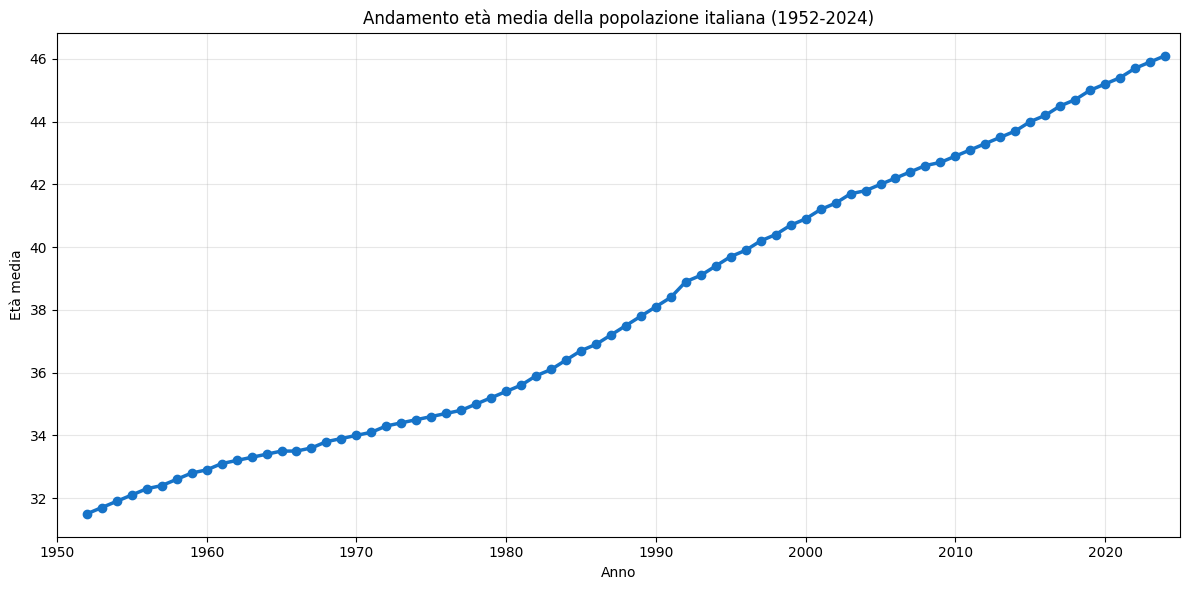

In [70]:
#GRAFICO
plt.figure(figsize=(12,6))
plt.plot(df_etàmedia['Anno'], df_etàmedia['Età_media'], 
         marker='o', linewidth=2.5, color='#1673C8')
plt.title('Andamento età media della popolazione italiana (1952-2024)')
plt.xlabel('Anno')
plt.xlim(left=1950, right=2025)
plt.ylabel('Età media')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eta_media.png', dpi=300)
plt.show()

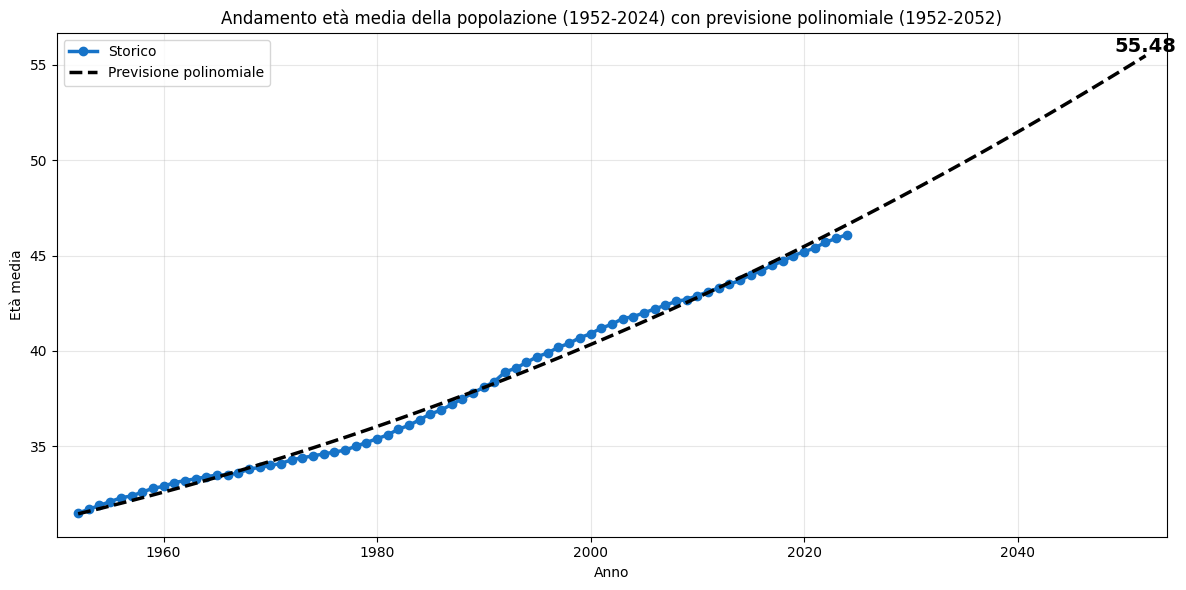

In [71]:
#Età popolazione con previsione con curva polinomiale
X=df_etàmedia['Anno'].values.reshape(-1, 1)
y=df_etàmedia['Età_media'].values
poly=PolynomialFeatures(degree=2)
X_poly=poly.fit_transform(X)

model=LinearRegression()
model.fit(X_poly, y)

#Previsione fino al 2052
EM_futuro=np.arange(df_etàmedia['Anno'].max()+1, 2053)
EM_tot=np.concatenate([df_etàmedia['Anno'], EM_futuro])
EM_tot_poly=poly.transform(EM_tot.reshape(-1, 1))
y_pred=model.predict(TF_tot_poly)

#Grafico
plt.figure(figsize=(12,6))
plt.plot(df_etàmedia['Anno'], df_etàmedia['Età_media'], 
         marker='o', linewidth=2.5, color='#1673C8', 
         label='Storico')
plt.plot(EM_tot, y_pred,
         linestyle='dashed', linewidth=2.5, color='black',
         label='Previsione polinomiale')
plt.title('Andamento età media della popolazione (1952-2024) con previsione polinomiale (1952-2052)')
plt.xlabel('Anno')
plt.xlim(left=1950, right=2054)
plt.ylabel('Età media')
plt.grid(True, alpha=0.3)
plt.legend()

#Valore 2052
anno_2052=np.array([[2052]])
valore_2052=model.predict(poly.transform(anno_2052))[0]

plt.text(2052, valore_2052,
         f"{valore_2052:.2f}",
         fontsize=14, fontweight='bold',
         ha='center', va='bottom')

plt.tight_layout()
plt.savefig('eta_media_previsione_polinomiale.png', dpi=300)
plt.show()
